# Credit Card Fraud Detection — Modeling

## 1. Approach
We compare four approaches to handle severe class imbalance (0.17% fraud):
1. Logistic Regression + SMOTE — baseline
2. XGBoost + SMOTE — main model
3. XGBoost + SMOTE + GridSearchCV — hyperparameter tuning
4. XGBoost + scale_pos_weight — final model
5. XGBoost + scale_pos_weight + GridSearchCV — hyperparameter tuning

Train/test split is done manually before all pipelines.
SMOTE is applied only inside the pipeline — never touches the test set.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score,
                             roc_auc_score, classification_report, average_precision_score)
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import PrecisionRecallDisplay
import joblib

In [2]:
df = pd.read_csv("../data/creditcard.csv")

In [3]:
preprocessor = ColumnTransformer([
    ("scaler", StandardScaler(), ["Amount", "Time"])
], remainder="passthrough")

In [4]:
pipeline_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE()),
    ("model", LogisticRegression())
])

In [5]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 2. Logistic Regression + SMOTE — Baseline

**Why Logistic Regression first?**
Simple, fast, interpretable — perfect as a baseline to understand
the minimum performance we need to beat.

**Why SMOTE?**
With only 492 fraud cases out of 284,807, the model never "sees" enough
fraud examples. SMOTE generates synthetic fraud samples between existing ones
— only on train set, never on test.

**Pipeline:**
```
ColumnTransformer (StandardScaler on Amount & Time)
    → SMOTE (only during fit)
    → LogisticRegression
```

In [6]:
pipeline_lr.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [7]:
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
pr_auc_lr = average_precision_score(y_test, y_pred_proba_lr)

print(classification_report(y_test, y_pred_lr, target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC LR: {roc_auc_lr:.4f}")
print(f"PR-AUC LR:  {pr_auc_lr:.4f}")

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC LR: 0.9702
PR-AUC LR:  0.7246


In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_lr = cross_val_score(pipeline_lr, X, y, cv=cv, scoring='average_precision')
scores_lr, scores_lr.mean(), scores_lr.std()

(array([0.71455225, 0.73218997, 0.73892687, 0.78173366, 0.73591035]),
 np.float64(0.7406626206242809),
 np.float64(0.022207945809949593))

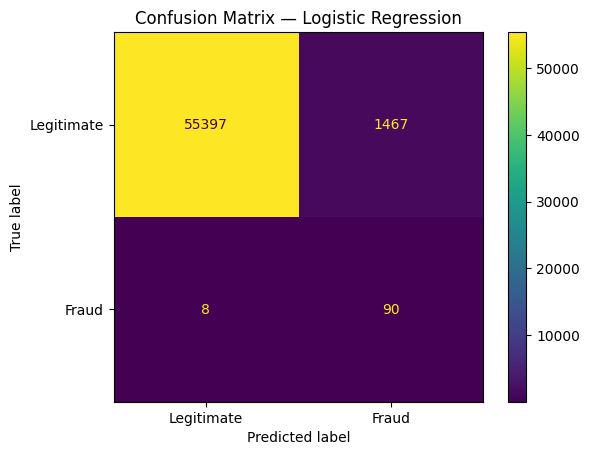

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=["Legitimate", "Fraud"]
)
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

## 3. Logistic Regression Results

| Metric | Fraud class |
|--------|-------------|
| Precision | 0.06 |
| Recall | 0.92 |
| F1 | 0.11 |
| PR-AUC | 0.7264 |
| CV PR-AUC | 0.7403 ± 0.0222 |

**Precision 0.06** — 94% of fraud alerts are false alarms. Unacceptable in production.
**Recall 0.92** — catches most fraud, but at too high a cost.
**Conclusion:** Strong baseline for Recall, terrible for Precision. PR-AUC 0.73 is our target to beat.

**Next:** XGBoost — better at handling non-linear patterns and imbalance.

## 4. XGBoost + SMOTE

**Why XGBoost?**
Unlike Logistic Regression, XGBoost handles non-linear patterns and feature
interactions automatically. It's one of the best models for tabular data.

**Why still SMOTE?**
Same reasoning as LR — we need to balance classes before training.
SMOTE only applied to train set via Pipeline.

**Pipeline:**
```
ColumnTransformer (StandardScaler on Amount & Time)
    → SMOTE (only during fit)
    → XGBClassifier()
```

In [10]:
pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE()),
    ("model", XGBClassifier())
])

In [11]:
pipeline_xgb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [12]:
y_pred_xgb = pipeline_xgb.predict(X_test)
y_pred_proba_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
pr_auc_xgb = average_precision_score(y_test, y_pred_proba_xgb)

print(classification_report(y_test, y_pred_xgb, target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC XGB: {roc_auc_xgb:.4f}")
print(f"PR-AUC XGB:  {pr_auc_xgb:.4f}")

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.72      0.88      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC XGB: 0.9809
PR-AUC XGB:  0.8688


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_xgb = cross_val_score(pipeline_xgb, X, y, cv=cv, scoring='average_precision')
scores_xgb, scores_xgb.mean(), scores_xgb.std()

(array([0.84874492, 0.88535317, 0.86907037, 0.84459887, 0.82687076]),
 np.float64(0.8549276171097226),
 np.float64(0.020287077627116387))

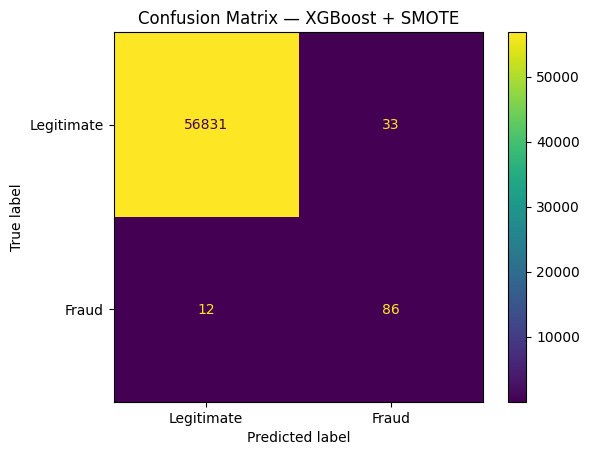

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=["Legitimate", "Fraud"]
)
plt.title("Confusion Matrix — XGBoost + SMOTE")
plt.show()

## 4. XGBoost + SMOTE Results

| Metric | LR | XGBoost | Δ |
|--------|-----|---------|---|
| Precision | 0.06 | 0.69 | +0.63 ↑ |
| Recall | 0.92 | 0.87 | -0.05 ↓ |
| F1 | 0.11 | 0.77 | +0.66 ↑ |
| PR-AUC | 0.73 | 0.87 | +0.14 ↑ |
| CV PR-AUC | 0.74 ± 0.02 | 0.85 ± 0.02 | — |

**Massive improvement in Precision** — from 6% to 69%. Classic precision-recall tradeoff: Recall dropped slightly (0.92 → 0.87) but the gain in Precision is worth it.

**Business impact:** Per 100 fraud alerts — LR: 94 false alarms, XGBoost: 31 false alarms.

**Next:** GridSearchCV to tune max_depth, learning_rate, n_estimators.

## 5. Hyperparameter Tuning XGBoost SMOTE — GridSearchCV

The baseline XGBoost showed good results, but we can improve further.
We search over key hyperparameters:

- `max_depth` — controls tree depth, higher = more complex model
- `learning_rate` — step size for each boosting round
- `n_estimators` — number of trees in the ensemble

**Scoring metric:** PR-AUC.
**CV strategy:** StratifiedKFold to preserve class ratio in each fold.

In [15]:
param_grid = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__n_estimators': [100, 200]
}

grid_search = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid,
    cv=5,
    scoring='average_precision',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.2f}")
print(f"Test set evaluation score: {grid_search.score(X_test, y_test):.2f}")

Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200}
Best cross-validation score: 0.84
Test set evaluation score: 0.87


In [16]:
best_model = grid_search.best_estimator_
y_pred_best_model = best_model.predict(X_test)
y_pred_proba_best_model = best_model.predict_proba(X_test)[:, 1]
roc_auc_best_model = roc_auc_score(y_test, y_pred_proba_best_model)
pr_auc_best_model = average_precision_score(y_test, y_pred_proba_best_model)

print(classification_report(y_test, y_pred_best_model, target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC XGB with GridSearch: {roc_auc_best_model:.4f}")
print(f"PR-AUC XGB with GridSearch:  {pr_auc_best_model:.4f}")

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.70      0.85      0.76        98

    accuracy                           1.00     56962
   macro avg       0.85      0.92      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC XGB with GridSearch: 0.9766
PR-AUC XGB with GridSearch:  0.8660


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_best_model = cross_val_score(best_model, X, y, cv=cv, scoring='average_precision')
scores_best_model, scores_best_model.mean(), scores_best_model.std()

(array([0.84862847, 0.89098418, 0.87202376, 0.8371869 , 0.83091836]),
 np.float64(0.8559483359285955),
 np.float64(0.022441041371302674))

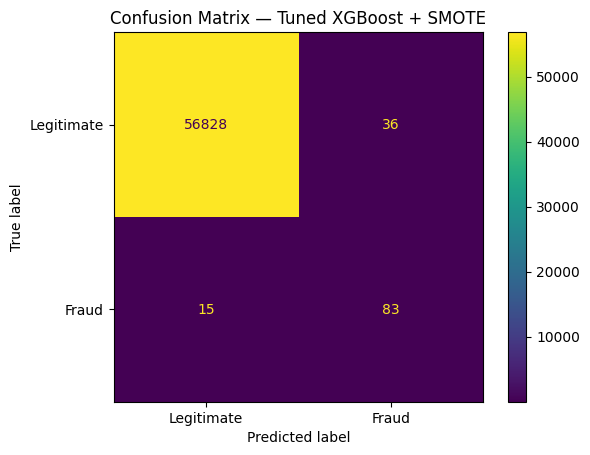

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best_model,
    display_labels=["Legitimate", "Fraud"]
)
plt.title("Confusion Matrix — Tuned XGBoost + SMOTE")
plt.show()

## 6. Tuned XGBoost + SMOTE Results

| Metric | XGBoost | Tuned XGBoost | Δ |
|--------|---------|---------------|---|
| Precision | 0.69 | 0.67 | -0.02 ↓ |
| Recall | 0.87 | 0.86 | -0.01 ↓ |
| F1 | 0.77 | 0.75 | -0.02 ↓ |
| PR-AUC | 0.87 | 0.86 | -0.01 ↓ |

**Best params found:** `learning_rate=0.1`, `max_depth=7`, `n_estimators=200`

**Conclusion:** GridSearchCV confirmed baseline parameters were already near-optimal.
Minimal improvement — baseline XGBoost wins over tuned version.

**Next:** Try scale_pos_weight instead of SMOTE — more natural approach for tree-based models.

## 7. XGBoost + scale_pos_weight

**Why scale_pos_weight?**
Instead of generating synthetic data, we tell XGBoost directly:
"mistakes on fraud cost 578x more than mistakes on legitimate transactions."

`scale_pos_weight = count(negative) / count(positive) = 284,315 / 492 ≈ 578`

This works at the loss function level — more natural for tree-based models
and doesn't introduce artificial data points.

**Pipeline:**
```
ColumnTransformer (StandardScaler on Amount & Time)
    → SMOTE (only during fit)
    → XGBClassifier(scale_pos_weight=578)
```

In [19]:
pipeline_spw = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(scale_pos_weight=578))
])

In [20]:
pipeline_spw.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [21]:
y_pred_spw = pipeline_spw.predict(X_test)
y_pred_proba_spw = pipeline_spw.predict_proba(X_test)[:, 1]
roc_auc_spw = roc_auc_score(y_test, y_pred_proba_spw)
pr_auc_spw = average_precision_score(y_test, y_pred_proba_spw)

print(classification_report(y_test, y_pred_spw, target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC: {roc_auc_spw:.4f}")
print(f"PR-AUC:  {pr_auc_spw:.4f}")

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9721
PR-AUC:  0.8771


In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_spw = cross_val_score(pipeline_spw, X, y, cv=cv, scoring='average_precision')
scores_spw, scores_spw.mean(), scores_spw.std()

(array([0.8418207 , 0.91247318, 0.87419732, 0.85723784, 0.81967947]),
 np.float64(0.8610816998768062),
 np.float64(0.03134648287448087))

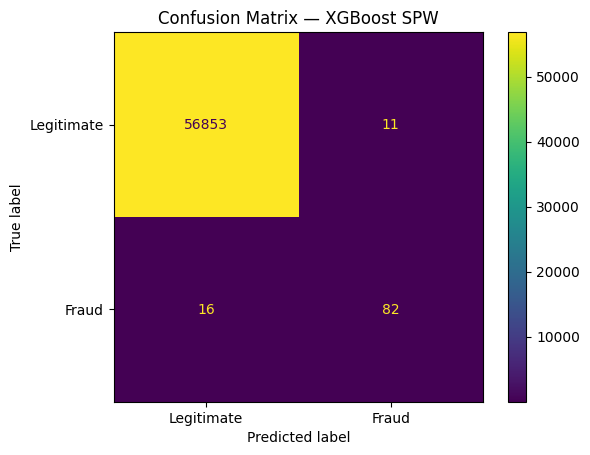

In [23]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_spw,
    display_labels=["Legitimate", "Fraud"]
)
plt.title("Confusion Matrix — XGBoost SPW")
plt.show()

## 8. XGBoost + scale_pos_weight Results

| Metric | LR+SMOTE | XGB+SMOTE | XGB+SPW | Δ vs XGB+SMOTE |
|--------|----------|-----------|---------|----------------|
| Precision | 0.06 | 0.69 | **0.88** | +0.19 ↑ |
| Recall | 0.92 | 0.87 | 0.84 | -0.03 ↓ |
| F1 | 0.11 | 0.77 | **0.86** | +0.09 ↑ |
| PR-AUC | 0.73 | 0.87 | **0.88** | +0.01 ↑ |
| CV PR-AUC | 0.74±0.02 | 0.85±0.02 | 0.86±0.03 | — |

## 9. Hyperparameter Tuning XGBoost SPW — GridSearchCV

Same search space as before — checking if SPW benefits from tuning.

- `max_depth` — controls tree complexity
- `learning_rate` — step size per boosting round  
- `n_estimators` — number of trees

**Scoring metric:** PR-AUC — most honest metric for imbalanced fraud data.

In [24]:
param_grid_spw = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__n_estimators': [100, 200]
}

grid_search_spw = GridSearchCV(
    estimator=pipeline_spw,
    param_grid=param_grid_spw,
    cv=5,
    scoring='average_precision',
    n_jobs=-1
)

grid_search_spw.fit(X_train, y_train)
print(f"Best parameters: {grid_search_spw.best_params_}")
print(f"Best CV score: {grid_search_spw.best_score_:.2f}")
print(f"Test score: {grid_search_spw.score(X_test, y_test):.2f}")

Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200}
Best CV score: 0.85
Test score: 0.88


In [25]:
best_model_spw = grid_search_spw.best_estimator_
y_pred_best_spw = best_model_spw.predict(X_test)
y_pred_proba_best_spw = best_model_spw.predict_proba(X_test)[:, 1]
roc_auc_best_spw = roc_auc_score(y_test, y_pred_proba_best_spw)
pr_auc_best_spw = average_precision_score(y_test, y_pred_proba_best_spw)

print(classification_report(y_test, y_pred_best_spw, target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC: {roc_auc_best_spw:.4f}")
print(f"PR-AUC:  {pr_auc_best_spw:.4f}")

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9754
PR-AUC:  0.8793


In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_best_spw = cross_val_score(best_model_spw, X, y, cv=cv, scoring='average_precision')
scores_best_spw, scores_best_spw.mean(), scores_best_spw.std()

(array([0.84479284, 0.90215025, 0.8761788 , 0.85342273, 0.8322378 ]),
 np.float64(0.8617564827670898),
 np.float64(0.0247718779733181))

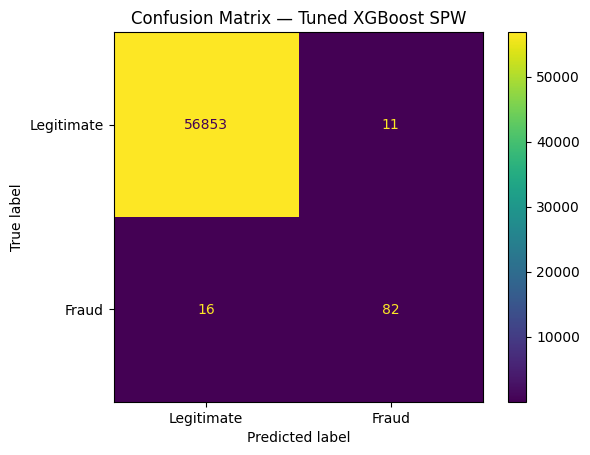

In [27]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best_spw,
    display_labels=["Legitimate", "Fraud"]
)
plt.title("Confusion Matrix — Tuned XGBoost SPW")
plt.show()

## 9. Tuned XGBoost SPW Results

| Metric | XGBoost SPW | Tuned XGBoost SPW | Δ |
|--------|------------|-------------------|---|
| Precision | 0.88 | 0.88 | 0.00 |
| Recall | 0.84 | 0.84 | 0.00 |
| F1 | 0.86 | 0.86 | 0.00 |
| PR-AUC | 0.88 | 0.88 | 0.00 |
| CV PR-AUC | 0.86 ± 0.03 | 0.86 ± 0.02 | 0.00 |

**Best params:** `learning_rate=0.1`, `max_depth=7`, `n_estimators=200`

**Conclusion:** Tuning confirmed baseline SPW parameters were already optimal.
No improvement from GridSearch.

## 10. Final Model Comparison & Decision

| Metric | LR+SMOTE | XGB+SMOTE | Tuned XGB+SMOTE | XGB+SPW | Tuned XGB+SPW |
|--------|----------|-----------|-----------------|---------|---------------|
| Precision | 0.06 | 0.69 | 0.67 | **0.88** | **0.88** |
| Recall | 0.92 | 0.87 | 0.86 | 0.84 | 0.84 |
| F1 | 0.11 | 0.77 | 0.75 | **0.86** | **0.86** |
| PR-AUC | 0.73 | 0.87 | 0.86 | **0.88** | **0.88** |
| CV PR-AUC | 0.74±0.02 | 0.85±0.02 | 0.86±0.02 | 0.86±0.03 | 0.86±0.02 |

**Why PR-AUC over ROC-AUC?**
ROC-AUC is misleading for imbalanced data — it accounts for True Negatives
(284K legitimate transactions) which inflates the score. PR-AUC focuses only
on Precision and Recall — exactly what matters for fraud.

**Why scale_pos_weight over SMOTE?**
- No synthetic data — model learns real patterns only
- Better Precision — fewer false alarms
- Faster training

**Final model:** `best_model_spw` saved to `models/fraud_model.pkl`

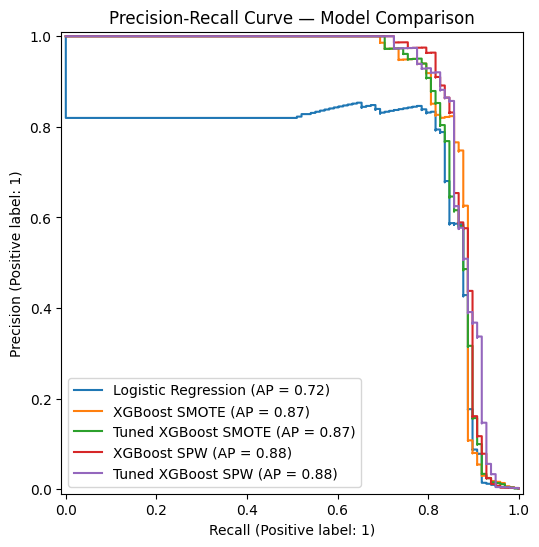

In [31]:

fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_estimator(pipeline_lr, X_test, y_test,
                                       ax=ax, name="Logistic Regression")
PrecisionRecallDisplay.from_estimator(pipeline_xgb, X_test, y_test,
                                       ax=ax, name="XGBoost SMOTE")
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test,
                                       ax=ax, name="Tuned XGBoost SMOTE")
PrecisionRecallDisplay.from_estimator(pipeline_spw, X_test, y_test,
                                       ax=ax, name="XGBoost SPW")
PrecisionRecallDisplay.from_estimator(best_model_spw, X_test, y_test,
                                       ax=ax, name="Tuned XGBoost SPW")

plt.title("Precision-Recall Curve — Model Comparison")
plt.show()

In [29]:
joblib.dump(pipeline_spw, "../models/fraud_model.pkl")
print("Model saved!")

Model saved!
